# 机器学习
## 1.iris数据集 机器学习内含有内置的数据集
引入方式：

前面提到的是鸢尾花iris数据集，我们通过load_iris加载进来，实际上SKLearn有三种引入数据形式。

0- 打包好的数据：对于小数据集，用sklearn.datasets.load_*
1- 分流下载数据：对于大数据集，用sklearn.datasets.fetch_*
2- 随机创建数据：为了快速展示，用sklearn.datasets.make_*
## 2. 估计器的使用
估计器首先被创建，然后被拟合。

创建估计器：需要设置一组超参数，比如

线性回归里超参数normalize=True
K均值里超参数n_clusters=5
拟合估计器：需要训练集

在监督学习中的代码范式为model.fit(X_train, y_train)
在无监督学习中的代码范式为model.fit(X_train)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

       species  
0       setosa  
1       setosa  
2       setosa  
147  virginica  
148  virginica  
149  virginica  


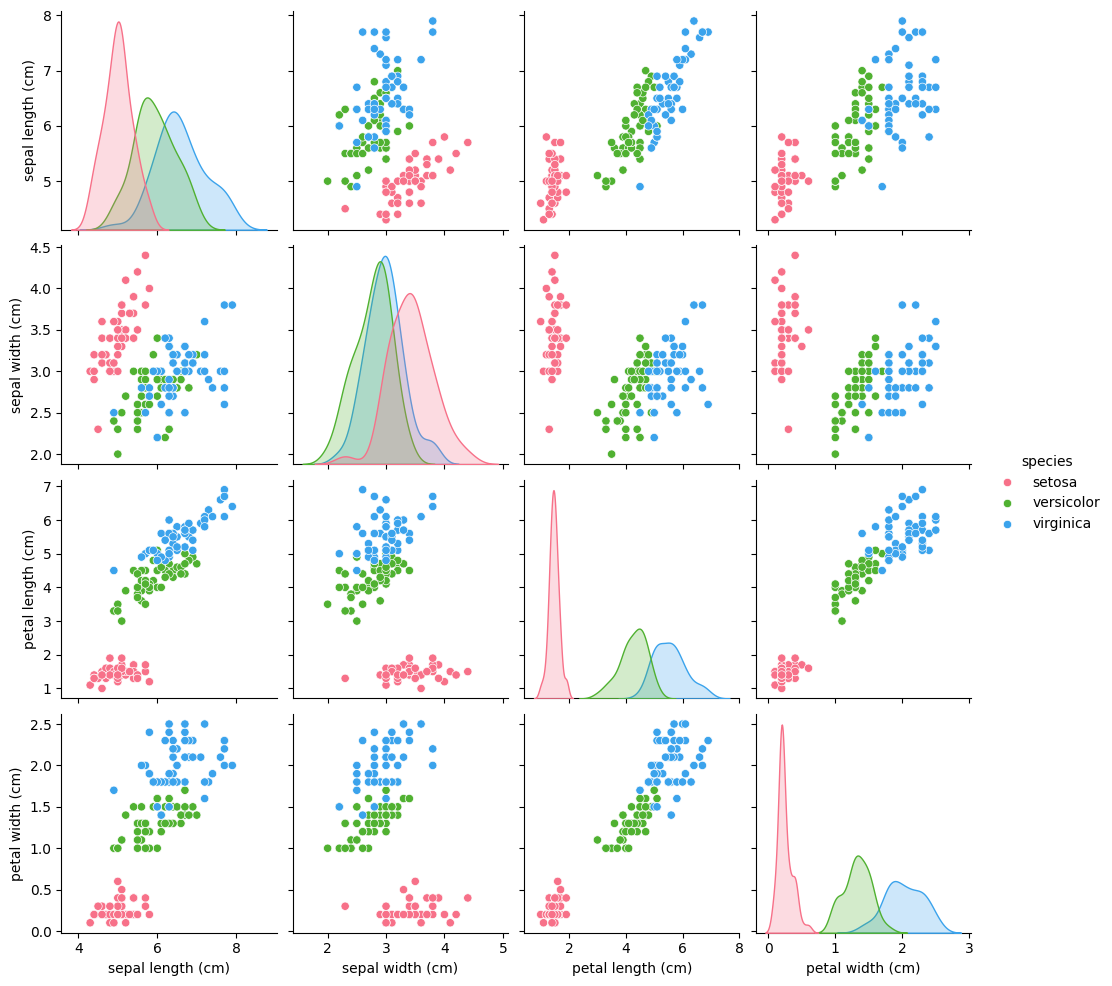

In [7]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns

iris = load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data['species'] = iris.target_names[iris.target]    
print(pd.concat([iris_data.head(3), iris_data.tail(3)]))
sns.pairplot( iris_data, hue='species', palette='husl' )


## 创建估计器
1） 线性回归 设置超参数normalize为True（在每个特征值上做标准化，这样能保证拟合的稳定性，加速模型拟合速度），最新版移除。
2） k均值

### 拟合估计器
监督学习 model.fit(trainX,trainY)
无监督学习 model.fit(trainX)

### 拟合后
线性回归：model.coef_
k均值：model.labels_

线性回归
X = [[1], [2], [3], [4]]  # 特征
y = [3, 5, 7, 9]     # 目标值
model.fit( X, y )

ŷ = 0.999... + 2.0 × X 
ŷ 是预测值
X 是输入特征
0.999... 是截距（≈1.0）  print(model.intercept_)
2.0 是系数 print(model.coef_)


k均值
聚类

model.clustercenters：簇中心。三个簇意味着有三个坐标。
model.labels_：聚类后的标签。
model.inertia_：所有点到对应的簇中心的距离平方和(越小越好)


# 有监督学习
from sklearn.xxx import SomeModel
# xxx 可以是 linear_model 或 ensemble 等
model = SomeModel( hyperparameter )
model.fit( X, y )
# 无监督学习
from sklearn.xxx import SomeModel
# xxx 可以是 cluster 或 decomposition 等
model = SomeModel( hyperparameter )
model.fit( X )



In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression() # 创建线性回归模型
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
from sklearn.cluster import KMeans    
model = KMeans( n_clusters=3 )    
model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
from sklearn.datasets import load_iris    
iris = load_iris()
X = iris.data[:,0:2]    
model.fit(X)
print( model.cluster_centers_, '\
')    
print( model.labels_, '\
' )    
print( model.inertia_, '\
')    
print(iris.target)

[[5.00392157 3.40980392]
 [6.82391304 3.07826087]
 [5.8        2.7       ]] 
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 2 1 2 1 2 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2
 1 1 1 1 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 1 1 0 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 2 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2] 
37.08627024722933 
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## 预测器
预测器是估计器做的一个延展，具备对数据进行预测的功能。

预测器最常见的是predict()函数：

model.predict(X_test)：评估模型在新数据上的表现。
model.predict(X_train)：确认模型在老数据上的表现。
为了进行新数据评估，我们先将数据分成80:20的训练集(X_train, y_train)和测试集(X_test, y_test)，再用从训练集上拟合fit()的模型在测试集上预测predict()。

In [21]:
from sklearn.datasets import load_iris    
iris = load_iris()
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train , y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
print( 'The size of X_train is ', X_train.shape )    
print( 'The size of y_train is ', y_train.shape )    
print( 'The size of X_test is ', X_test.shape )    
print( 'The size of y_test is ', y_test.shape )

The size of X_train is  (120, 4)
The size of y_train is  (120,)
The size of X_test is  (30, 4)
The size of y_test is  (30,)


In [23]:
y_pred = model.predict(X_test) # 预测的类别

print(y_test)
print(y_pred)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[ 1.23071715 -0.04010441  2.21970287  1.34966889  1.28429336  0.02248402
  1.05726124  1.82403704  1.36824643  1.06766437  1.70031437 -0.07357413
 -0.15562919 -0.06569402 -0.02128628  1.39659966  2.00022876  1.04812731
  1.28102792  1.97283506  0.03184612  1.59830192  0.09450931  1.91807547
  1.83296682  1.87877315  1.78781234  2.03362373  0.03594506  0.02619043]


score & decision_function

预测器里还有额外的两个函数可以使用。在分类问题中：

score()返回的是分类准确率。
decision_function()返回的是每个样例在每个类下的分数值。

# model.score(X_test, y_test) 实际上做了两件事：
def score(self, X_test, y_test):
    # 第一步：用X_test生成预测值
    y_pred = self.predict(X_test)
    
    # 第二步：计算y_pred和y_test之间的R²分数
    r2 = r2_score(y_test, y_pred)
    
    return r2

In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = model.score(X_test, y_test)
# 均方根误差
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 平均绝对误差
mae = mean_absolute_error(y_test, y_pred)

print(f"R² 分数: {r2:.4f}")  # 0.9469
print(f"RMSE: {rmse:.4f}")    # 需要计算
print(f"MAE: {mae:.4f}")      # 需要计算


R² 分数: 0.9469
RMSE: 0.1926
MAE: 0.1464


## 转换器
转换器是一种估计器，也有拟合功能，对比预测器做完拟合来预测，转换器做完拟合来转换。核心点如下：

估计器里fit + predict
转换器里fit + transform

① LabelEncoder&OrdinalEncoder
② OneHotEncoder

1）将类别型变量(categorical)编码成数值型变量(numerical)  
2）规范化(normalize)或标准化(standardize)数值型变量，特征缩放

## 原始数据（文本类别）
原始数据: ['红色', '蓝色', '绿色', '红色']

## LabelEncoder 转换为数值
LabelEncoder: [2, 0, 1, 2]

## OneHotEncoder 转换为独热编码
OneHotEncoder: 
[[0., 0., 1.],  # 红色 → [0,0,1]
 [1., 0., 0.],  # 蓝色 → [1,0,0]
 [0., 1., 0.],  # 绿色 → [0,1,0]
 [0., 0., 1.]]  # 红色 → [0,0,1]

 # (2) 特征缩放
数据要做的最重要的转换之一是特征缩放(feature scaling)。类似逻辑回归，神经网络这种计算型模型，对于不同特征的幅度大小差异是敏感的。

具体来说，对于某个特征，我们有两种变换方法：

标准化(standardization)：每个维度的特征减去该特征均值，除以该维度的标准差。
规范化(normalization)：每个维度的特征减去该特征最小值，除以该特征的最大值与最小值之差。

In [32]:
from sklearn.preprocessing import MinMaxScaler    
X = np.array( [0, 0.5, 1, 1.5, 2, 100] )    
X_scale = MinMaxScaler().fit_transform( X.reshape(-1,1) )    
X_scale

array([[0.   ],
       [0.005],
       [0.01 ],
       [0.015],
       [0.02 ],
       [1.   ]])

② StandardScaler
StandardScaler做的事情是调整数据分布，尽量接近正态分布。

In [ ]:
from sklearn.preprocessing import StandardScaler    
X_scale = StandardScaler().fit_transform( X.reshape(-1,1) )    
X_scale